In [1]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from PIL import Image



In [ ]:
# Bộ dữ liệu Kaggle Cats and Dogs: 2 folder con Cat/ và Dog/
data_dir = 'PetImages'
categories = ['Cat', 'Dog']

filepaths = []
labels = []
skipped = 0
for label, category in enumerate(categories):
    folder = os.path.join(data_dir, category)
    for fname in os.listdir(folder):
        if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue
        fpath = os.path.join(folder, fname)
        try:
            Image.open(fpath).verify()
        except Exception:
            skipped += 1  # Ảnh hỏng: bỏ qua
            continue
        filepaths.append(fpath)
        labels.append(label)

df = pd.DataFrame({'filepath': filepaths, 'label': labels})
print(f"Tổng số ảnh: {len(df)}")
print(f"Phân bố nhãn:\n{df['label'].value_counts().rename({0: 'Cat', 1: 'Dog'})}")
print(f"Đã bỏ qua {skipped} file không đọc được (ảnh hỏng/file rác).")

# Hàm tiền xử lý ảnh bằng PIL + numpy (không cần torchvision)
def preprocess_image(filepath):
    img = Image.open(filepath).convert('RGB')
    img = img.resize((150, 150))                    # Resize
    img_array = np.array(img, dtype=np.float32) / 255.0  # ToTensor: [0, 1]
    img_array = (img_array - 0.5) / 0.5             # Normalize: [-1, 1]
    img_array = np.transpose(img_array, (2, 0, 1))  # HWC -> CHW (PyTorch format)
    return img_array

class CatsDogsDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['filepath']
        label = self.df.iloc[idx]['label']
        image = preprocess_image(img_path)
        return torch.tensor(image, dtype=torch.float32), torch.tensor(label, dtype=torch.long)

# Ưu tiên GPU nếu có
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")



Tổng số ảnh: 200
Phân bố nhãn:
label
Cat    100
Dog    100
Name: count, dtype: int64
Đã bỏ qua 0 file không đọc được (ảnh hỏng/file rác).
Device: cpu


In [ ]:
# Chia bộ dữ liệu Train (80%) và Validation (20%)
train_df, val_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['label']
)

torch.manual_seed(42)

# Đóng gói DataLoader
BATCH_SIZE = 32

train_dataset = CatsDogsDataset(train_df)
val_dataset = CatsDogsDataset(val_df)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Hàm mất mát và bộ tối ưu
criterion = nn.CrossEntropyLoss()



In [ ]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        # Khối tích chập 1: Conv2D(32, 3x3, ReLU) -> MaxPool(2x2) -> Dropout(0.2)
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.2)
        )

        # Khối tích chập 2: Conv2D(64, 3x3, ReLU) -> MaxPool(2x2) -> Dropout(0.2)
        self.block2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.2)
        )

        # Khối tích chập 3: Conv2D(128, 3x3, ReLU) -> MaxPool(2x2) -> Dropout(0.2)
        self.block3 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.2)
        )

        # Khối Fully Connected: Flatten -> Linear(128, ReLU) -> Output(2)
        self.flatten = nn.Flatten()
        self.fc = nn.Sequential(
            nn.Linear(128 * 18 * 18, 128),  # 150 -> 75 -> 37 -> 18 (sau 3 lần pool)
            nn.ReLU()
        )
        self.output = nn.Linear(128, 2)  # 2 no-ron: Cat và Dog

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.flatten(x)
        x = self.fc(x)
        x = self.output(x)
        return x

# Khởi tạo mô hình
model = CNN().to(device)
print("\nKiến trúc CNN:")
print(model)

# Bộ tối ưu Adam
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 15
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(num_epochs):
    # --- Train ---
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # --- Validation ---
    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(val_loader)
    val_acc = val_correct / val_total
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f'Epoch [{epoch+1}/{num_epochs}] | '
          f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')




Kiến trúc CNN:
CNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Dropout(p=0.2, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Dropout(p=0.2, inplace=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Dropout(p=0.2, inplace=False)
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc): Sequential(
    (0): Linear(in_features=41472, out_features=128, bias=True)
    (1): ReLU()
  )
  (output): Linear(in_features=128, out_features=2, bias=True)
)
Epoch [1/15] | Train Loss: 1.9597, Tra

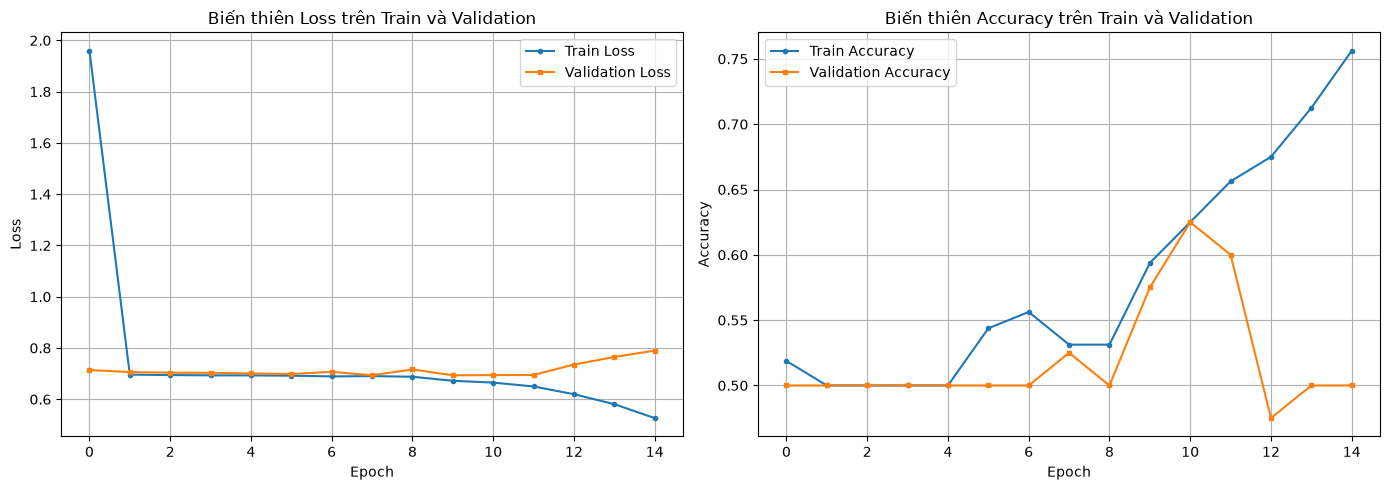


Overall Accuracy trên Validation: 0.5000


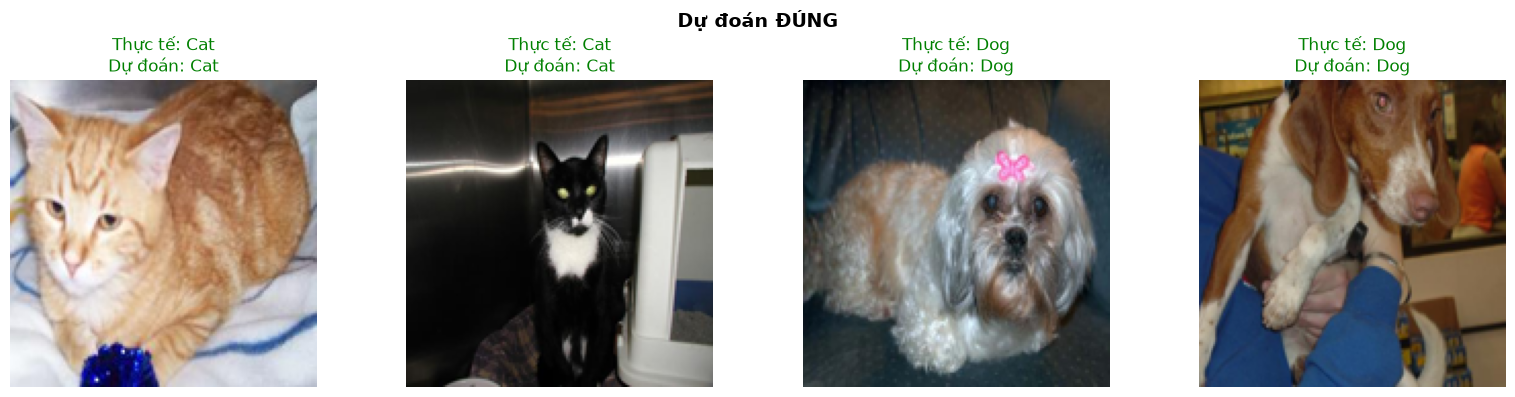

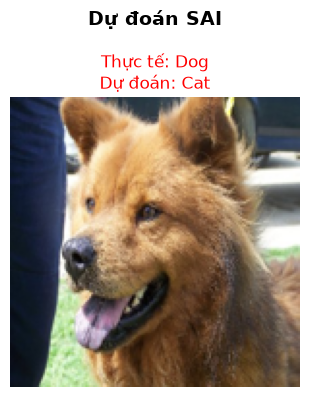

Kết quả huấn luyện:
Accuracy cuối cùng - Train: 0.7562, Validation: 0.5000


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, label='Train Loss', marker='o', markersize=3)
ax1.plot(val_losses, label='Validation Loss', marker='s', markersize=3)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Biến thiên Loss trên Train và Validation')
ax1.legend()
ax1.grid(True)

ax2.plot(train_accuracies, label='Train Accuracy', marker='o', markersize=3)
ax2.plot(val_accuracies, label='Validation Accuracy', marker='s', markersize=3)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Biến thiên Accuracy trên Train và Validation')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('cnn_training_curves.png', dpi=150)
plt.show()

# Overall Accuracy trên Validation
print(f"\nOverall Accuracy trên Validation: {val_accuracies[-1]:.4f}")

# Dự đoán đúng: 4 ảnh (2 Cat, 2 Dog)
# Dự đoán sai: 1 ảnh
model.eval()
label_names = {0: 'Cat', 1: 'Dog'}

correct_samples = {0: [], 1: []}  # {label: [(image, true, pred), ...]}
wrong_samples = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        for i in range(len(labels)):
            true_l = labels[i].item()
            pred_l = predicted[i].item()
            if true_l == pred_l and len(correct_samples[true_l]) < 2:
                correct_samples[true_l].append((images[i], true_l, pred_l))
            elif true_l != pred_l and len(wrong_samples) < 1:
                wrong_samples.append((images[i], true_l, pred_l))

        # Đủ mẫu thì dừng
        if (len(correct_samples[0]) >= 2 and len(correct_samples[1]) >= 2
                and len(wrong_samples) >= 1):
            break

# Vẽ dự đoán đúng
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Dự đoán ĐÚNG', fontsize=14, fontweight='bold')
idx = 0
for label in [0, 1]:
    for img, true_l, pred_l in correct_samples[label]:
        ax = axes[idx]
        img_show = img.permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5  # De-normalize
        ax.imshow(np.clip(img_show, 0, 1))
        ax.set_title(f'Thực tế: {label_names[true_l]}\nDự đoán: {label_names[pred_l]}', color='green')
        ax.axis('off')
        idx += 1
plt.tight_layout()
plt.savefig('cnn_correct_predictions.png', dpi=150)
plt.show()

# Vẽ dự đoán sai
if wrong_samples:
    img, true_l, pred_l = wrong_samples[0]
    fig, ax = plt.subplots(1, 1, figsize=(4, 4))
    img_show = img.permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5
    ax.imshow(np.clip(img_show, 0, 1))
    ax.set_title(f'Thực tế: {label_names[true_l]}\nDự đoán: {label_names[pred_l]}', color='red')
    ax.axis('off')
    fig.suptitle('Dự đoán SAI', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('cnn_wrong_prediction.png', dpi=150)
    plt.show()

print("Kết quả huấn luyện:")
print(f"Accuracy cuối cùng - Train: {train_accuracies[-1]:.4f}, Validation: {val_accuracies[-1]:.4f}")

#1. Tại sao một số loài dễ bị nhầm lẫn?
#
#   - Mèo mặt cụt (Persian), chó cỡ nhỏ (Chihuahua/Pomeranian):
#     Đặc điểm thị giác overlap cao với loài kia. Chó nhỏ lông dài
#     trông giống mèo, mèo mặt phẳng (Persian) trông giống chó.
#     Kích thước cơ thể nhỏ, tỷ lệ đầu/thân tương tự.
#
#   - Chó/mèo lông dài hoặc góc chụp mập, tròn:
#     Khi lông dài che mất đặc điểm nhận dạng (tai, mũi, đuôi),
#     hình dạng tổng thể trở nên tròn đều → CNN khó phân biệt.
#     Góc chụp nghiêng/xa làm mất tỷ lệ đặc trưng.
#
#   → Mô hình dựa vào texture (lông) và shape (tai, mũi) nên
#     khi các đặc điểm này bị ẩn hoặc biến đổi, xác suất nhầm tăng.
#
#2. Vai trò của Dropout(0.2) sau mỗi Max Pooling?
#
#   - Vai trò: Dropout ngẫu nhiên "tắt" 20% neuron trong quá trình
#     huấn luyện, buộc mô hình học nhiều feature redundancy thay vì
#     dựa vào một nhóm neuron cố định. Giảm overfitting.
#
#   - Nếu loại bỏ Dropout:
#     + Mô hình dễ memorize dữ liệu train (overfitting).
#     + Train Accuracy tăng cao, Validation Accuracy thấp → gap lớn.
#     + Biểu đồ Loss: Validation Loss bắt đầu tăng sau vài epoch
#       trong khi Train Loss tiếp tục giảm (dấu hiệu overfitting rõ).
